In [1]:
import sys
import os
import numpy as np
import importlib

# Remontée de deux niveaux pour accéder à Data_loader
current_dir = os.getcwd()
project_root = os.path.normpath(os.path.join(current_dir, "..", ".."))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

print(f"Chemin du projet : {project_root}")

# Import du module de chargement des données
module_name = "RSA_deep_working.Data_loader.class_data_loaders"

try:
    class_data_loaders = importlib.import_module(module_name)
    DirectoryRSAClass = class_data_loaders.DirectoryRSAClass
except ModuleNotFoundError as e:
    print(f"Erreur lors de l'importation du module {module_name} : {e}")
    sys.exit(1)

Chemin du projet : /home/loai/Test/RSMLExtraction


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import transforms
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import rsml
import tifffile


from RSA_deep_working.Data_loader.class_data_loaders import DirectoryRSAClass

# importing pretrained segmentation model
import segmentation_models_pytorch as smp
from torch.utils.tensorboard import SummaryWriter

writer = SummaryWriter(log_dir="runs/uc1_segmentation")
global_step = 0


2025-03-28 10:01:04.394345: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-03-28 10:01:04.401094: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1743152464.408800  984153 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1743152464.411119  984153 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-03-28 10:01:04.419483: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

In [3]:
import torch
from torch.utils.data import Dataset, DataLoader

# Dimensions d'origine
H, W = (1166, 1348)

# Première étape : division par 4
H_temp = H // 4  # 1166 // 4 = 291
W_temp = W // 4  # 1348 // 4 = 337

# Deuxième étape : ajustement pour être divisible par 32
H_new = (H_temp // 32) * 32  # 291 // 32 = 9, 9 * 32 = 288
W_new = (W_temp // 32) * 32  # 337 // 32 = 10, 10 * 32 = 320

print("Dimensions après division par 4 :", H_temp, W_temp)
print("Dimensions ajustées (multiples de 32) :", H_new, W_new)

img_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize((H_new, W_new), interpolation=transforms.InterpolationMode.BILINEAR),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

mask_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize((H_new, W_new), interpolation=transforms.InterpolationMode.NEAREST),
])

class RSASeg2DDataset(Dataset):
    def __init__(self, rsa_dir_loader, img_transform=None, mask_transform=None):
        self.samples = []
        self.img_transform = img_transform
        self.mask_transform = mask_transform
        for loader in rsa_dir_loader.loaders:
            img_path = loader.image_stack_path
            mask_path = loader.date_map_path
            with tifffile.TiffFile(img_path) as tif:
                num_slices = len(tif.pages)
            for z in range(num_slices):
                self.samples.append((img_path, mask_path, z))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, mask_path, z = self.samples[idx]
        img = tifffile.imread(img_path, key=z)
        mask_loaded = tifffile.imread(mask_path)
        mask = np.zeros_like(img)
        mask[mask_loaded <= z + 1] = 1
        mask[mask_loaded == 0] = 0
        mask = mask.astype(np.float32)


        if self.img_transform:
            img = self.img_transform(img)
            mask = self.mask_transform(mask)
        return img, mask
    
    def get_sample(self, idx):
        # for a given index, return the whole time serie and the mask at the same index
        img_path, mask_path, z = self.samples[idx]
        img_paths = []
        mask_paths = []
        times = []
        # find time 0 of the serie
        idx_0 = idx - z
        print(idx_0)
        img_path, mask_path, z = self.samples[idx_0]
            
        #load the whole serie and the mask
        img = tifffile.imread(img_path)
        mask_loaded = tifffile.imread(mask_path)
        
        return img, mask_loaded
            

# Instanciation
base_directory = "/home/loai/Test/data/UC1_data"
dir_loader = DirectoryRSAClass(base_directory, load_date_map=True, lazy=True)
rsa_dataset = RSASeg2DDataset(dir_loader, img_transform=img_transform, mask_transform=mask_transform)

print(len(rsa_dataset))

# plot image and mask
def plot_img_mask(img: torch.Tensor, mask: torch.Tensor):
    # img et mask ont shape [1, H, W]
    img_np  = img.squeeze(0).cpu().numpy()   # → (H, W)
    mask_np = mask.squeeze(0).cpu().numpy()

    fig, (ax0, ax1) = plt.subplots(1,2, figsize=(10,5))
    ax0.imshow(img_np, cmap='gray')
    ax0.set_title("Image")
    ax1.imshow(mask_np, cmap='gray')
    ax1.set_title("Mask")
    plt.show()
    print(f"Image shape : {img_np.shape}, mask shape : {mask_np.shape}")
    # Affichage de superposition
    fig, ax = plt.subplots(1,1, figsize=(5,5))
    ax.imshow(img_np, cmap='gray')
    ax.imshow(mask_np, cmap='jet', alpha=0.5)
    ax.set_title("Superposition")
    plt.show()


# Instanciation
print(len(rsa_dataset))

train_set, val_set = torch.utils.data.random_split(rsa_dataset, [int(0.8*len(rsa_dataset)), len(rsa_dataset)-int(0.8*len(rsa_dataset))])
print(len(train_set) , len(val_set))
def evaluate(model, loader, device, loss_fn):
    model.eval()
    total_loss = 0.0
    total_iou = 0.0
    total_dice = 0.0
    n = 0

    with torch.no_grad():
        for imgs, masks in tqdm(loader, desc="Evaluation iteration", position=1, leave=False, dynamic_ncols=True):
            imgs, masks = imgs.to(device), masks.to(device)
            preds = model(imgs)
            loss_val = loss_fn(torch.sigmoid(preds), masks)
            total_loss += loss_val.item()

            probs = torch.sigmoid(preds)
            preds_bin = (probs > 0.5).float()
            intersection = (preds_bin * masks).sum(dim=(1,2,3))
            union = preds_bin.sum(dim=(1,2,3)) + masks.sum(dim=(1,2,3)) - intersection

            iou = (intersection / (union + 1e-6)).mean().item()
            dice = (2 * intersection / (preds_bin.sum(dim=(1,2,3)) + masks.sum(dim=(1,2,3)) + 1e-6)).mean().item()

            total_iou += iou
            total_dice += dice
            n += 1

    return total_loss / n, total_iou / n, total_dice / n


Dimensions après division par 4 : 291 337
Dimensions ajustées (multiples de 32) : 288 320
754
754
603 151


In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Utilisation du device : {device}")

# data loader optimization
train_loader = DataLoader(train_set, batch_size=16, shuffle=False, num_workers=4)
val_loader = DataLoader(val_set, batch_size=16, shuffle=False, num_workers=4)

Utilisation du device : cuda


In [5]:
# load models : model_DICE.pth, model_CLDice.pth, model_BCE.pth
model_BCE = smp.Unet(
    encoder_weights=None,
    decoder_attention_type=None,
    in_channels=1,
    classes=1
).to(device)

model_BCE_HEDT = smp.Unet(
    encoder_weights=None,
    decoder_attention_type=None,
    in_channels=1,
    classes=1
).to(device)

model_HEDT = smp.Unet(
    encoder_weights=None,
    decoder_attention_type=None,
    in_channels=1,
    classes=1
).to(device)


model_DICE = smp.Unet(
    encoder_weights=None,
    decoder_attention_type=None,
    in_channels=1,
    classes=1
).to(device)

model_CLDice_02 = smp.Unet(
    encoder_weights=None,
    decoder_attention_type=None,
    in_channels=1,
    classes=1
).to(device)

model_CLDice_05 = smp.Unet(
    encoder_weights=None,
    decoder_attention_type=None,
    in_channels=1,
    classes=1
).to(device)

model_CLDice_08 = smp.Unet(
    encoder_weights=None,
    decoder_attention_type=None,
    in_channels=1,
    classes=1
).to(device)

# load models
model_BCE.load_state_dict(torch.load("model_BCE_450epoch.pth"))
model_DICE.load_state_dict(torch.load("model_Dice_450epoch.pth"))
model_CLDice_02.load_state_dict(torch.load("model_CLDice_0,2_200epoch.pth"))
model_CLDice_05.load_state_dict(torch.load("model_CLDice_0,5_450epoch.pth"))
model_CLDice_08.load_state_dict(torch.load("model_CLDice_0,8_450epoch.pth"))
model_HEDT.load_state_dict(torch.load("model_HEDT_450epoch.pth"))
model_BCE_HEDT.load_state_dict(torch.load("model_BCE_HEDT_450epoch.pth"))

/tmp/ipykernel_984153/2435368648.py:53: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_BCE.load_state_dict(torch.load("model_BCE_450epoch.pth"))
/tmp/ipykernel_984153/2

<All keys matched successfully>

In [6]:
# print output shape and plot of model
batch = next(iter(train_loader))
imgs, masks = batch
imgs, masks = imgs.to(device), masks.to(device)
print(imgs.shape, masks.shape)

torch.Size([16, 1, 288, 320]) torch.Size([16, 1, 288, 320])


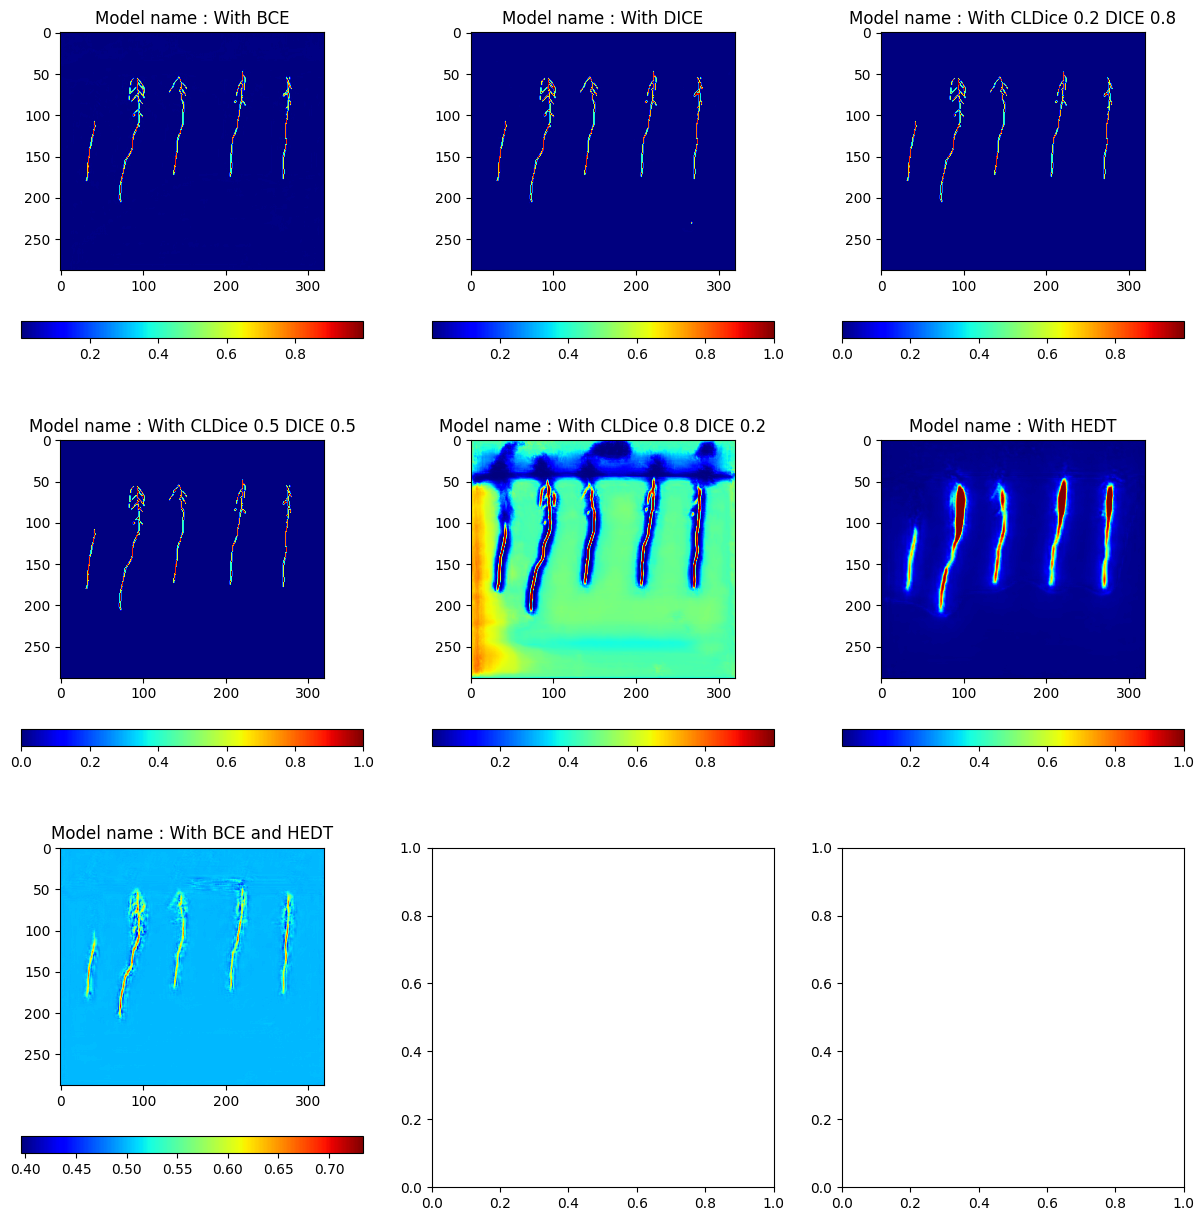

In [7]:
# plot prediction as probability map (density map) for all models
fig, axes = plt.subplots(3, 3, figsize=(15, 15))
axes = axes.ravel()
models = [model_BCE, model_DICE, model_CLDice_02, model_CLDice_05, model_CLDice_08, model_HEDT, model_BCE_HEDT]
model_names = ["With BCE", "With DICE", "With CLDice 0.2 DICE 0.8", "With CLDice 0.5 DICE 0.5", "With CLDice 0.8 DICE 0.2", "With HEDT", "With BCE and HEDT"]
for i, model in enumerate(models):
    model.eval()
    with torch.no_grad():
        pred = model(imgs)
        pred = torch.sigmoid(pred)
        pred = pred.squeeze(1).cpu().numpy()
        axes[i].imshow(pred[0], cmap='jet')
        axes[i].set_title(f"Model name : {model_names[i]}")
        # colorbar
        mappable = axes[i].images[0]
        fig.colorbar(mappable, ax=axes[i], orientation='horizontal')
plt.show()

In [ ]:
# get sample idx = 10
idx = 60
imgs, mask = rsa_dataset.get_sample(idx)
print(imgs.shape, mask.shape)

num_time = imgs.shape[0]
# create a new mask that consists of the superposition of all the predictions of the model BCE
mask_BCE = np.zeros_like(img_transform(mask), dtype=np.float32)
for i in range(num_time):
    img = imgs[i]
    img = img_transform(img)
    img = img.unsqueeze(0).to(device)
    model_BCE.eval()
    with torch.no_grad():
        pred = model_BCE(img) 
        pred = torch.sigmoid(pred)
        pred = pred.squeeze(0).cpu().numpy()  # Ensure pred has the same shape as mask_BCE
        # Convert pred to binary mask
        pred = (pred > 0.5).astype(np.float32) # shape (1, H, W)
        # Update mask_BCE only where it is zero
        mask_BCE[mask_BCE == 0] = pred[mask_BCE == 0] * (i+1)


58
(29, 1166, 1348) (1166, 1348)


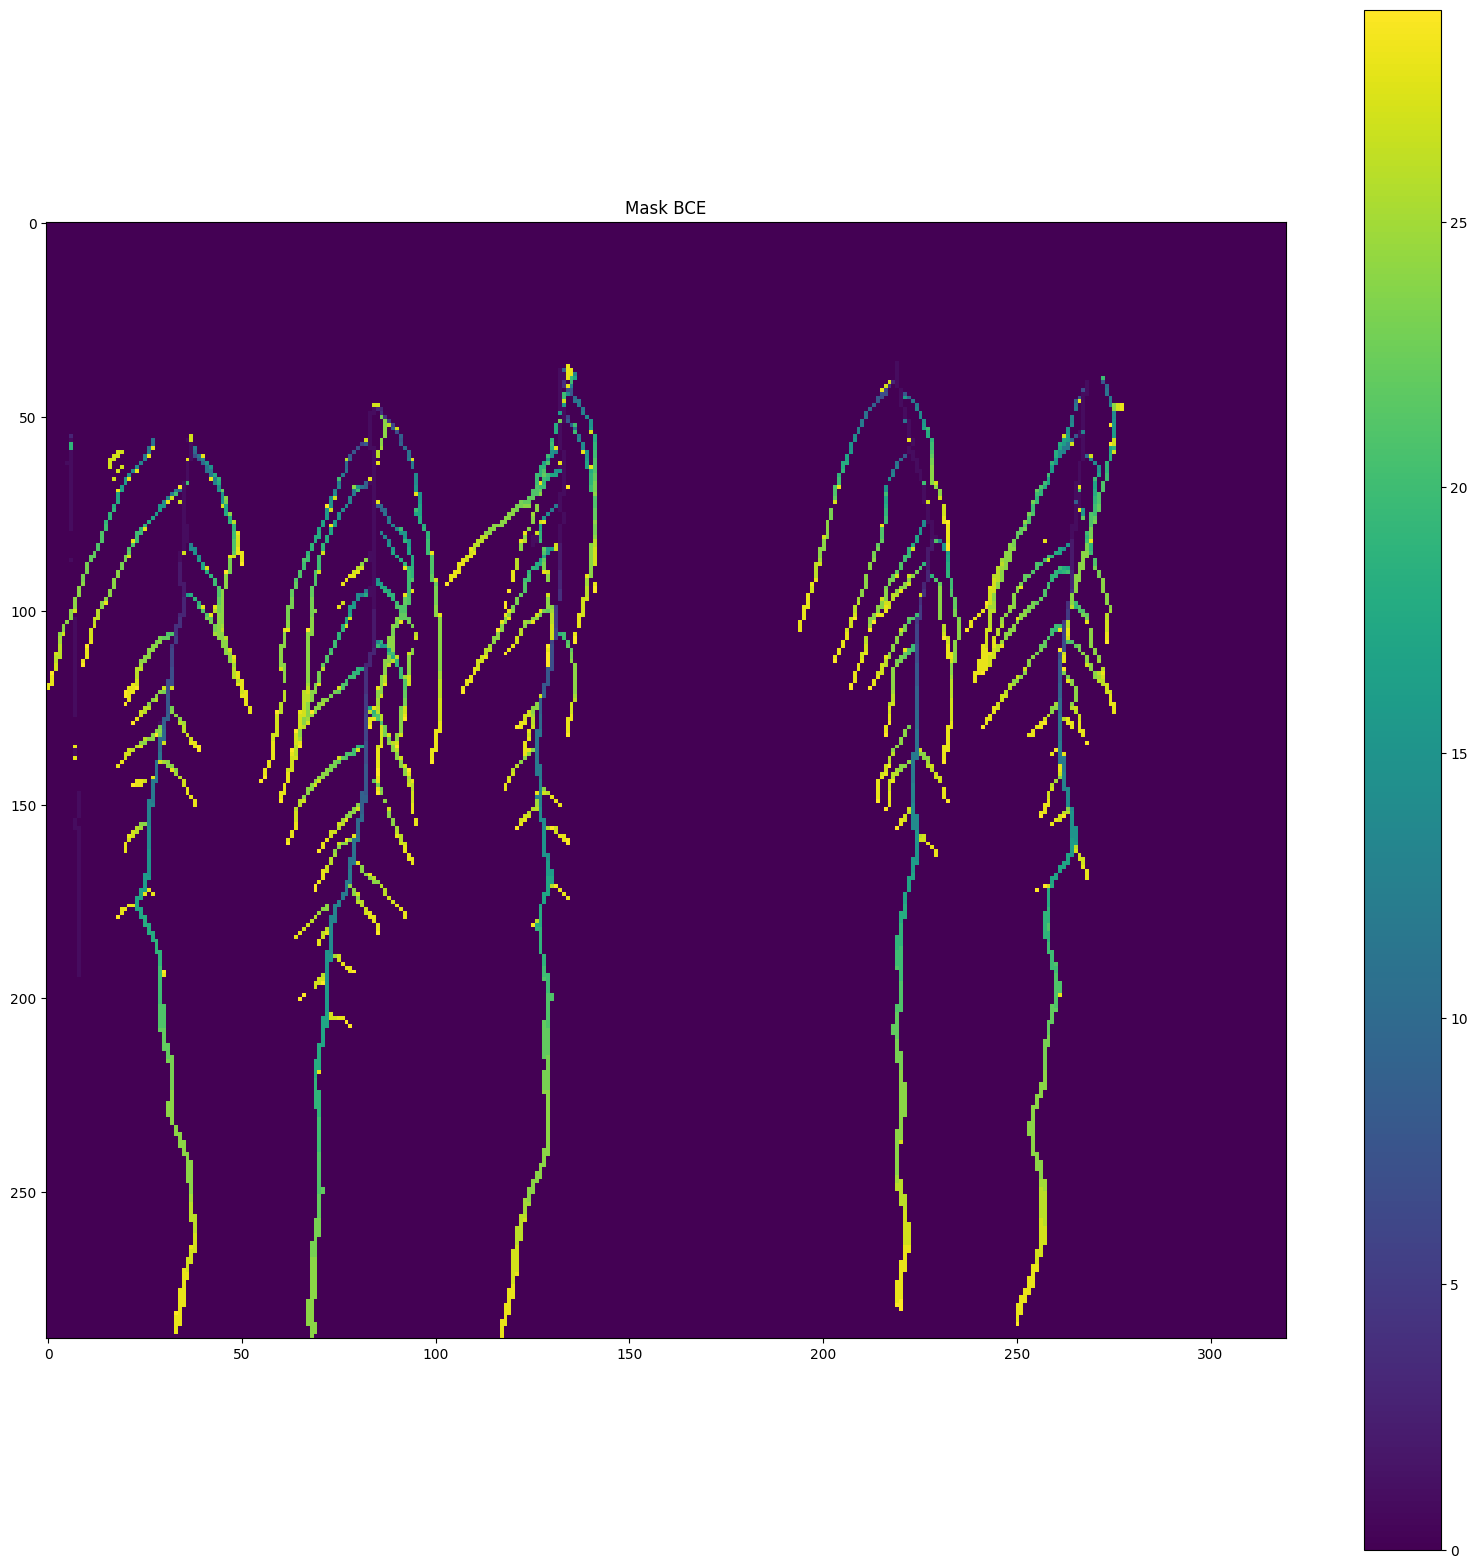

In [9]:
#plot the mask_BCE
plt.figure(figsize=(20,20))
plt.imshow(mask_BCE.squeeze(0))
plt.title("Mask BCE")
# colorbar
plt.colorbar()
plt.show()

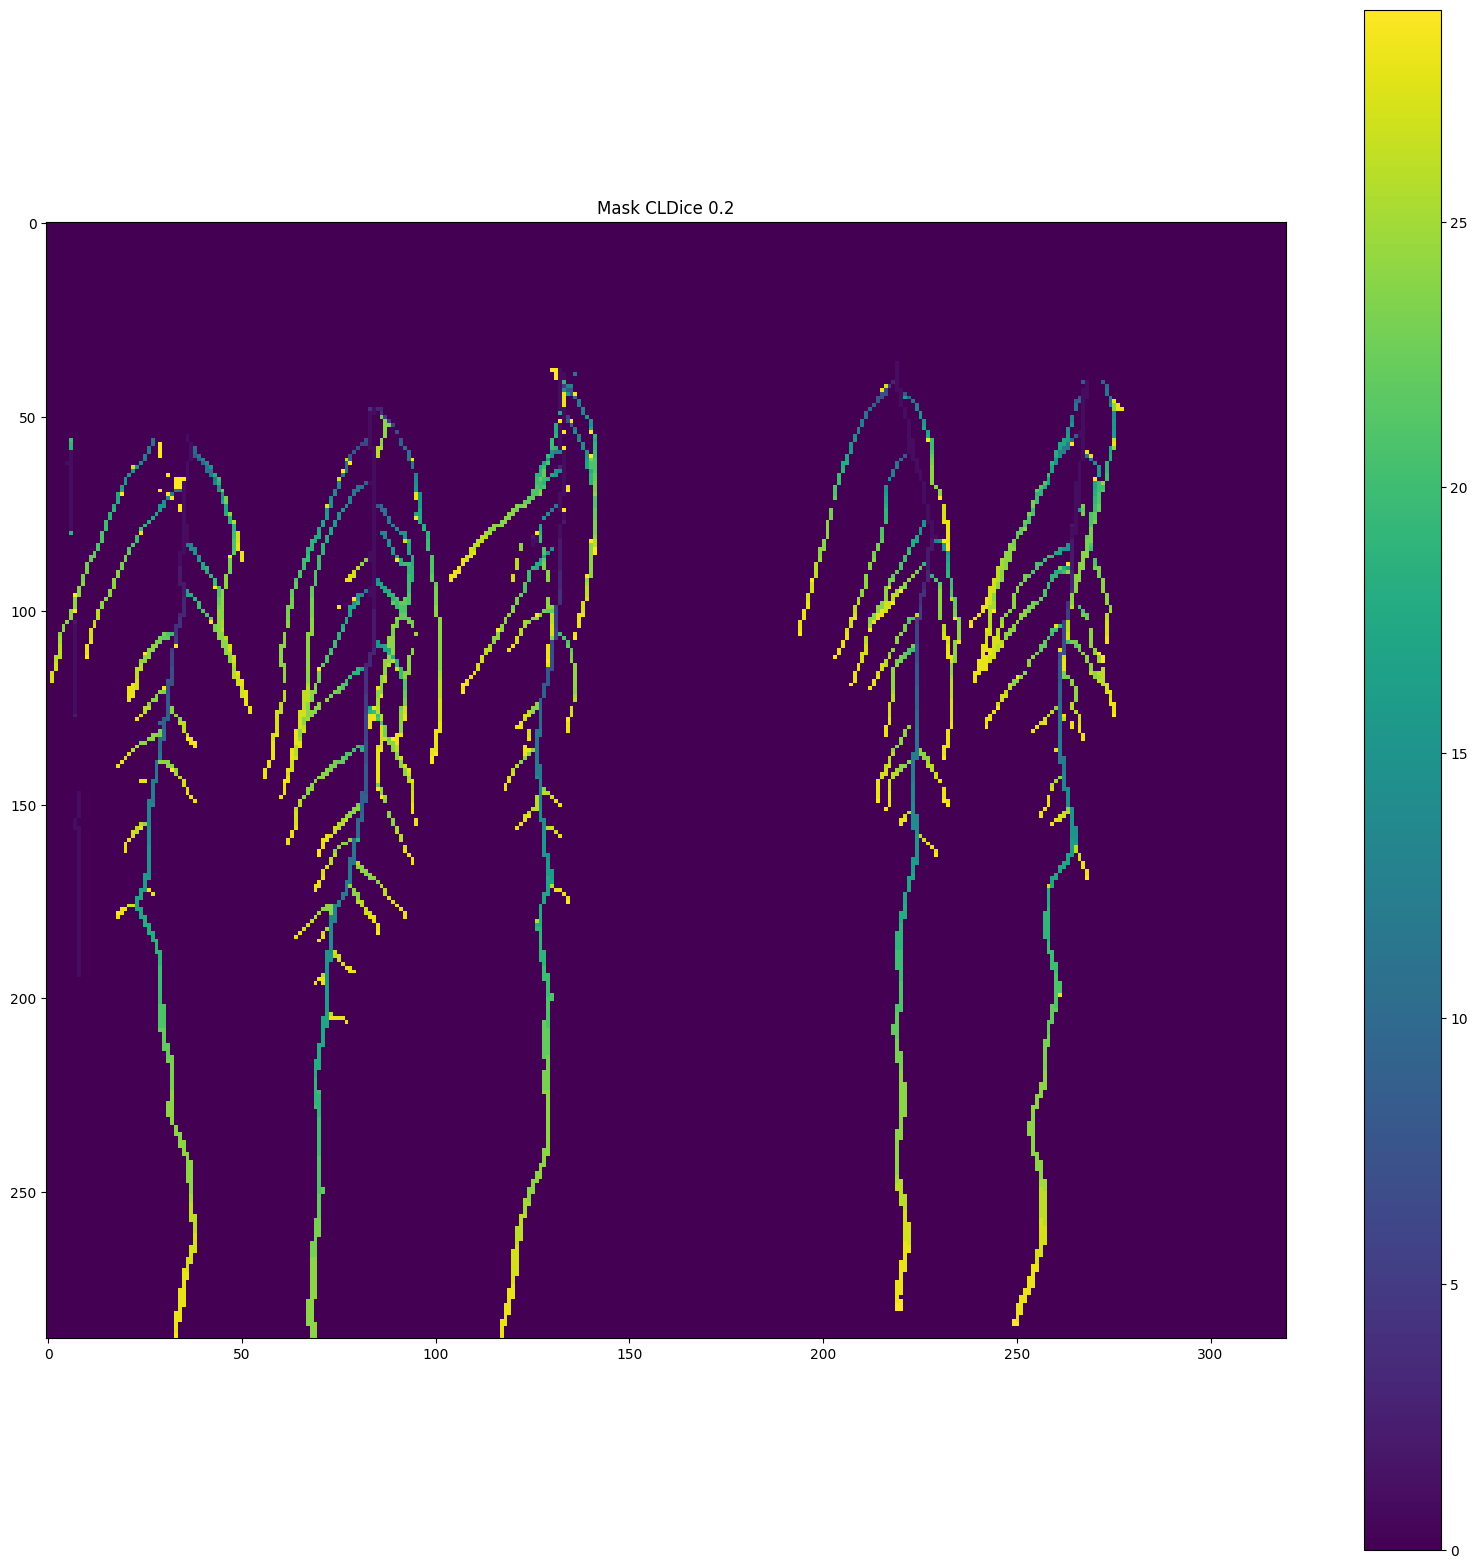

In [10]:
# same but with clDice 0.2
mask_CLDice_02 = np.zeros_like(img_transform(mask), dtype=np.float32)
for i in range(num_time):
    img = imgs[i]
    img = img_transform(img)
    img = img.unsqueeze(0).to(device)
    model_CLDice_02.eval()
    with torch.no_grad():
        pred = model_CLDice_02(img) 
        pred = torch.sigmoid(pred)
        pred = pred.squeeze(0).cpu().numpy()  # Ensure pred has the same shape as mask_BCE
        # Convert pred to binary mask
        pred = (pred > 0.5).astype(np.float32) # shape (1, H, W)
        # Update mask_BCE only where it is zero
        mask_CLDice_02[mask_CLDice_02 == 0] = pred[mask_CLDice_02 == 0] * (i+1)
        
#plot the mask_CLDice_02
plt.figure(figsize=(20,20))
plt.imshow(mask_CLDice_02.squeeze(0))
plt.title("Mask CLDice 0.2")
# colorbar
plt.colorbar()